# Reporting Results


> Envelope baseline

First reporting on the accuracies:

- load all subject summaries from `all_subs/sub-xxx/`
- keep only subjects with scalp EEG (`meta.eeg_config.scalp_only == True`)
- extract two-talker decoding accuracy from `summary_two_talker`
- color subjects by hearing group: normal hearing (NH) vs hearing impaired (HI)
- plot subject-wise decoding accuracy with a 50% chance-level line
- save a CSV table and figure for reporting

The same structure can later be reused for envelope+onsets and gamma by changing the folder/pattern configuration.


In [40]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Path setup
# --------------------------------------------------
# Assumes the notebook is inside the statistics folder.
# If you run it from statistics/, this will work directly.

STAT_DIR = Path.cwd()
PROJECT_ROOT = STAT_DIR.parent

# Input file from combine_results.py
TRIAL_RESULTS_PATH = STAT_DIR / "aad_trial_level_results.csv"

# Output folder for report figures
REPORT_FIG_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)

print("Statistics folder:", STAT_DIR)
print("Project root:", PROJECT_ROOT)
print("Trial results file:", TRIAL_RESULTS_PATH)
print("Figure output folder:", REPORT_FIG_DIR)

Statistics folder: c:\Projects\AAD_Fagprojekt_v2\statistics1
Project root: c:\Projects\AAD_Fagprojekt_v2
Trial results file: c:\Projects\AAD_Fagprojekt_v2\statistics1\aad_trial_level_results.csv
Figure output folder: c:\Projects\AAD_Fagprojekt_v2\reports\figures


In [41]:
trial_df = pd.read_csv(TRIAL_RESULTS_PATH)

print("Trial-level shape:", trial_df.shape)
display(trial_df.head())

# Keep only scalp-EEG model outputs
trial_df = trial_df[trial_df["scalp_only"] == True].copy()

print("\nNumber of subjects after filtering:", trial_df["subject"].nunique())
print("\nSubjects by hearing status:")
display(trial_df.groupby("hearing_status")["subject"].nunique())

# One row per subject for subject-wise accuracy plotting
subject_acc_df = (
    trial_df.groupby(["subject", "hearing_status", "group_HI"], as_index=False)
    .agg(
        decoding_accuracy=("correct", "mean"),
        n_trials=("correct", "size"),
        n_correct=("correct", "sum"),
    )
)

# Nice labels
subject_acc_df["group_label"] = subject_acc_df["hearing_status"].str.upper()

# Subject number for sorting
subject_acc_df["subject_num"] = (
    subject_acc_df["subject"].str.extract(r"(\d+)").astype(int)
)

# Sort HI first, then NH, or reverse if you prefer
subject_acc_df["group_order"] = subject_acc_df["group_label"].map({"HI": 0, "NH": 1})
subject_acc_df = subject_acc_df.sort_values(["group_order", "subject_num"]).reset_index(drop=True)

display(subject_acc_df.head())

Trial-level shape: (1408, 13)


,subject,hearing_status,group_HI,scalp_only,trial_index,r_att,r_ign,r_diff,correct,subject_decoding_accuracy,subject_n_trials,subject_n_correct,summary_path
0,sub-001,hi,1,True,0,0.108249,0.046398,0.061851,1,0.96875,32,31,results_baseline_all\sub-001\sub-001_backward_...
1,sub-001,hi,1,True,1,0.154476,0.016525,0.137951,1,0.96875,32,31,results_baseline_all\sub-001\sub-001_backward_...
2,sub-001,hi,1,True,2,0.071035,-0.007117,0.078152,1,0.96875,32,31,results_baseline_all\sub-001\sub-001_backward_...
3,sub-001,hi,1,True,3,0.117353,0.083574,0.033779,1,0.96875,32,31,results_baseline_all\sub-001\sub-001_backward_...
4,sub-001,hi,1,True,4,0.070426,-0.034507,0.104933,1,0.96875,32,31,results_baseline_all\sub-001\sub-001_backward_...



Number of subjects after filtering: 44

Subjects by hearing status:


hearing_status
hi    22
nh    22
Name: subject, dtype: int64

,subject,hearing_status,group_HI,decoding_accuracy,n_trials,n_correct,group_label,subject_num,group_order
0,sub-001,hi,1,0.96875,32,31,HI,1,0
1,sub-002,hi,1,1.00000,32,32,HI,2,0
2,sub-003,hi,1,0.75000,32,24,HI,3,0
3,sub-004,hi,1,0.90625,32,29,HI,4,0
4,sub-005,hi,1,0.90625,32,29,HI,5,0


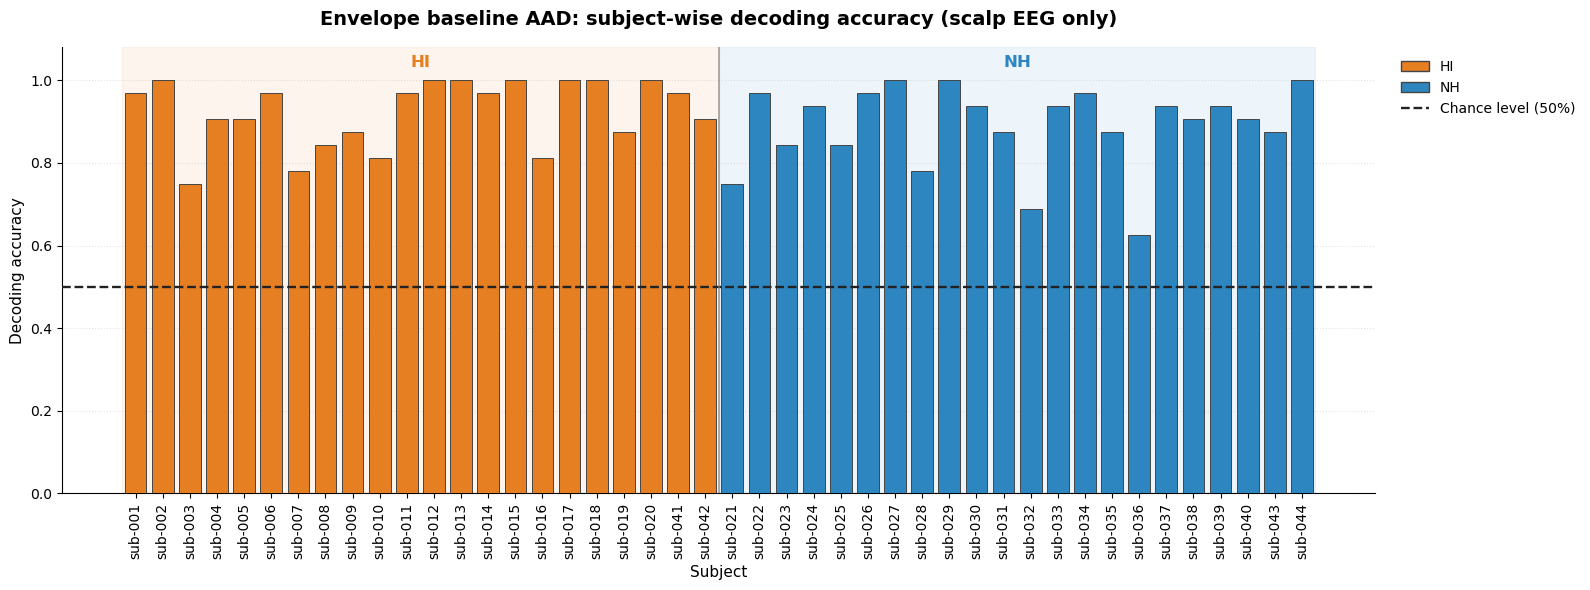

Saved figure to:
c:\Projects\AAD_Fagprojekt_v2\reports\figures\baseline_accuracy_plot.png
c:\Projects\AAD_Fagprojekt_v2\reports\figures\baseline_accuracy_plot.pdf


In [42]:
# --------------------------------------------------
# Plot subject-wise decoding accuracy
# --------------------------------------------------

# Output folder for report figures
REPORT_FIG_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Colors
COLOR_HI = "#E67E22"   # orange
COLOR_NH = "#2E86C1"   # blue
COLOR_CHANCE = "#222222"

# Make sure subjects are sorted clearly
plot_df = subject_acc_df.copy()

plot_df["subject_num"] = plot_df["subject"].str.extract(r"(\d+)").astype(int)
plot_df["group_order"] = plot_df["group_label"].map({"HI": 0, "NH": 1})
plot_df = plot_df.sort_values(["group_order", "subject_num"]).reset_index(drop=True)

# Bar positions and colors
x = np.arange(len(plot_df))
bar_colors = plot_df["group_label"].map({"HI": COLOR_HI, "NH": COLOR_NH})

fig, ax = plt.subplots(figsize=(16, 6))

# Light background shading for the two groups
hi_count = (plot_df["group_label"] == "HI").sum()
nh_count = (plot_df["group_label"] == "NH").sum()

if hi_count > 0:
    ax.axvspan(-0.5, hi_count - 0.5, color=COLOR_HI, alpha=0.08, zorder=0)

if nh_count > 0:
    ax.axvspan(hi_count - 0.5, len(plot_df) - 0.5, color=COLOR_NH, alpha=0.08, zorder=0)

# Bars
ax.bar(
    x,
    plot_df["decoding_accuracy"],
    color=bar_colors,
    edgecolor="#444444",
    linewidth=0.7,
    zorder=3,
)

# Chance level
ax.axhline(
    0.5,
    color=COLOR_CHANCE,
    linestyle="--",
    linewidth=1.7,
    label="Chance level (50%)",
    zorder=4,
)

# Separator between HI and NH
if hi_count > 0 and nh_count > 0:
    ax.axvline(
        hi_count - 0.5,
        color="gray",
        linewidth=1.2,
        alpha=0.7,
        zorder=5,
    )

# Group labels above plot
if hi_count > 0:
    ax.text(
        (hi_count - 1) / 2,
        1.025,
        "HI",
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold",
        color=COLOR_HI,
    )

if nh_count > 0:
    ax.text(
        hi_count + (nh_count - 1) / 2,
        1.025,
        "NH",
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold",
        color=COLOR_NH,
    )

# Axis formatting
ax.set_title(
    "Envelope baseline AAD: subject-wise decoding accuracy (scalp EEG only)",
    fontsize=14,
    weight="bold",
    pad=16,
)

ax.set_xlabel("Subject", fontsize=11)
ax.set_ylabel("Decoding accuracy", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["subject"], rotation=90)

ax.set_ylim(0, 1.08)
ax.yaxis.grid(True, linestyle=":", alpha=0.35, zorder=1)
ax.set_axisbelow(True)

# Cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend outside the plotting area
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_handles = [
    Patch(facecolor=COLOR_HI, edgecolor="#444444", label="HI"),
    Patch(facecolor=COLOR_NH, edgecolor="#444444", label="NH"),
    Line2D([0], [0], color=COLOR_CHANCE, linestyle="--", linewidth=1.7, label="Chance level (50%)"),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=False,
)

fig.tight_layout()

# Save figure
out_png = REPORT_FIG_DIR / "baseline_accuracy_plot.png"
out_pdf = REPORT_FIG_DIR / "baseline_accuracy_plot.pdf"

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

print("Saved figure to:")
print(out_png)
print(out_pdf)

> Delta correlation

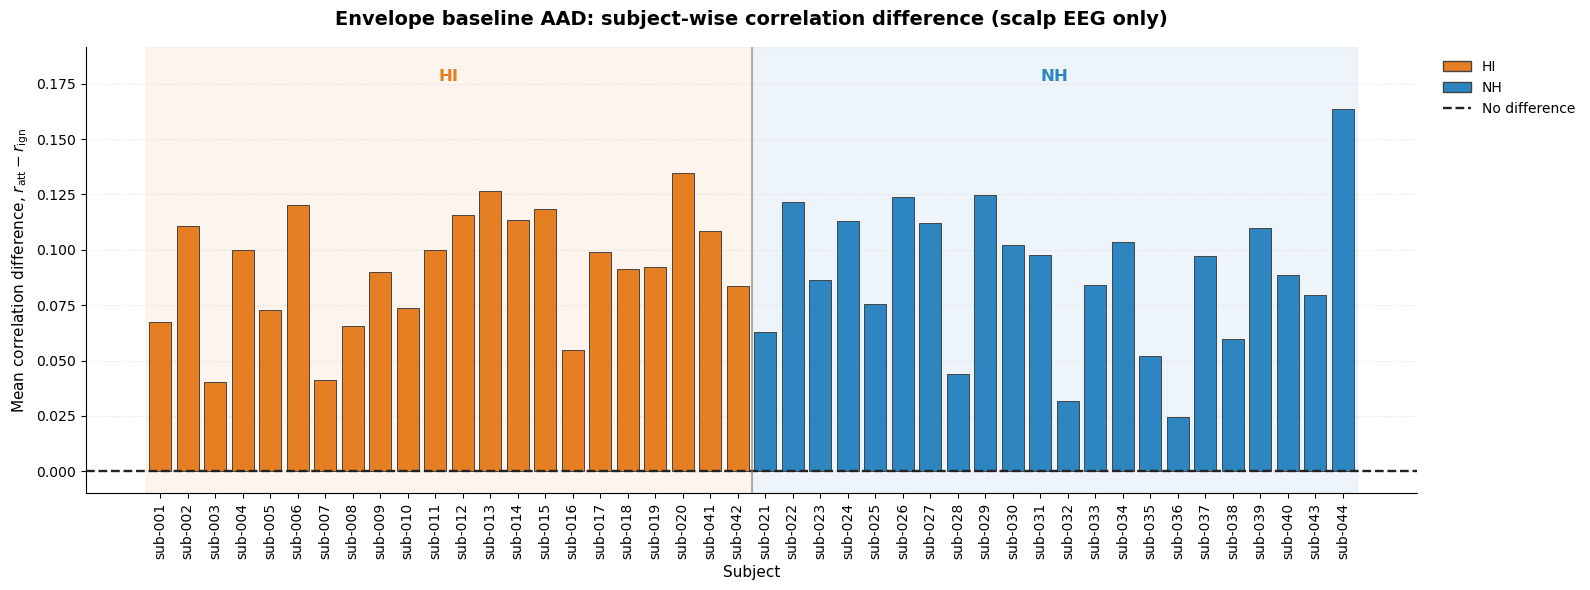

Saved figure to:
c:\Projects\AAD_Fagprojekt_v2\reports\figures\baseline_correlation_difference_plot.png


In [5]:
# --------------------------------------------------
# Plot subject-wise correlation difference
# --------------------------------------------------

# Output folder for report figures
REPORT_FIG_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Colors
COLOR_HI = "#E67E22"   # orange
COLOR_NH = "#2E86C1"   # blue
COLOR_ZERO = "#222222"

# --------------------------------------------------
# Prepare subject-wise delta correlations
# --------------------------------------------------

# Use trial-level results
delta_df = trial_df.copy()

# Keep only scalp EEG model outputs, if this column exists
if "scalp_only" in delta_df.columns:
    delta_df = delta_df[delta_df["scalp_only"] == True].copy()

# Make sure r_diff exists
# r_diff = correlation with attended speech - correlation with ignored speech
if "r_diff" not in delta_df.columns:
    delta_df["r_diff"] = delta_df["r_att"] - delta_df["r_ign"]

# One row per subject
subject_delta_df = (
    delta_df.groupby(["subject", "hearing_status", "group_HI"], as_index=False)
    .agg(
        mean_r_att=("r_att", "mean"),
        mean_r_ign=("r_ign", "mean"),
        mean_r_diff=("r_diff", "mean"),
        n_trials=("r_diff", "size"),
    )
)

# Nice group labels
subject_delta_df["group_label"] = subject_delta_df["hearing_status"].str.upper()

# Make sure subjects are sorted clearly
plot_df = subject_delta_df.copy()

plot_df["subject_num"] = plot_df["subject"].str.extract(r"(\d+)").astype(int)
plot_df["group_order"] = plot_df["group_label"].map({"HI": 0, "NH": 1})
plot_df = plot_df.sort_values(["group_order", "subject_num"]).reset_index(drop=True)

# Bar positions and colors
x = np.arange(len(plot_df))
bar_colors = plot_df["group_label"].map({"HI": COLOR_HI, "NH": COLOR_NH})

fig, ax = plt.subplots(figsize=(16, 6))

# Light background shading for the two groups
hi_count = (plot_df["group_label"] == "HI").sum()
nh_count = (plot_df["group_label"] == "NH").sum()

if hi_count > 0:
    ax.axvspan(-0.5, hi_count - 0.5, color=COLOR_HI, alpha=0.08, zorder=0)

if nh_count > 0:
    ax.axvspan(hi_count - 0.5, len(plot_df) - 0.5, color=COLOR_NH, alpha=0.08, zorder=0)

# Bars
ax.bar(
    x,
    plot_df["mean_r_diff"],
    color=bar_colors,
    edgecolor="#444444",
    linewidth=0.7,
    zorder=3,
)

# Zero line
ax.axhline(
    0,
    color=COLOR_ZERO,
    linestyle="--",
    linewidth=1.7,
    label=r"No difference ($r_{\mathrm{att}} - r_{\mathrm{ign}} = 0$)",
    zorder=4,
)

# Separator between HI and NH
if hi_count > 0 and nh_count > 0:
    ax.axvline(
        hi_count - 0.5,
        color="gray",
        linewidth=1.2,
        alpha=0.7,
        zorder=5,
    )

# Group labels above plot
ymax = plot_df["mean_r_diff"].max()
ymin = plot_df["mean_r_diff"].min()
yrange = ymax - ymin

if yrange == 0:
    yrange = 0.01

label_y = ymax + 0.08 * yrange

if hi_count > 0:
    ax.text(
        (hi_count - 1) / 2,
        label_y,
        "HI",
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold",
        color=COLOR_HI,
    )

if nh_count > 0:
    ax.text(
        hi_count + (nh_count - 1) / 2,
        label_y,
        "NH",
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold",
        color=COLOR_NH,
    )

# Axis formatting
ax.set_title(
    "Envelope baseline AAD: subject-wise correlation difference (scalp EEG only)",
    fontsize=14,
    weight="bold",
    pad=16,
)

ax.set_xlabel("Subject", fontsize=11)
ax.set_ylabel(r"Mean correlation difference, $r_{\mathrm{att}} - r_{\mathrm{ign}}$", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["subject"], rotation=90)

# Add some vertical spacing
lower_lim = min(ymin - 0.15 * yrange, -0.01)
upper_lim = label_y + 0.12 * yrange
ax.set_ylim(lower_lim, upper_lim)

ax.yaxis.grid(True, linestyle=":", alpha=0.35, zorder=1)
ax.set_axisbelow(True)

# Cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend outside the plotting area
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_handles = [
    Patch(facecolor=COLOR_HI, edgecolor="#444444", label="HI"),
    Patch(facecolor=COLOR_NH, edgecolor="#444444", label="NH"),
    Line2D([0], [0], color=COLOR_ZERO, linestyle="--", linewidth=1.7, label=r"No difference"),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=False,
)

fig.tight_layout()

# Save figure
out_png = REPORT_FIG_DIR / "baseline_correlation_difference_plot.png"

fig.savefig(out_png, dpi=300, bbox_inches="tight")

plt.show()

print("Saved figure to:")
print(out_png)

In [13]:
subject_delta_df

,subject,hearing_status,group_HI,mean_r_att,mean_r_ign,mean_r_diff,n_trials,group_label
0,sub-001,hi,1,0.115453,0.047847,0.067606,32,HI
1,sub-002,hi,1,0.126288,0.015743,0.110545,32,HI
2,sub-003,hi,1,0.090208,0.049740,0.040468,32,HI
3,sub-004,hi,1,0.168467,0.068659,0.099808,32,HI
4,sub-005,hi,1,0.083892,0.010932,0.072961,32,HI
5,sub-006,hi,1,0.146080,0.025861,0.120219,32,HI
6,sub-007,hi,1,0.051665,0.010531,0.041134,32,HI
7,sub-008,hi,1,0.099948,0.034397,0.065550,32,HI
8,sub-009,hi,1,0.161431,0.071312,0.090119,32,HI
9,sub-010,hi,1,0.093938,0.020336,0.073602,32,HI


In [15]:
subject_delta_df.mean_r_diff

0     0.067606
1     0.110545
2     0.040468
3     0.099808
4     0.072961
5     0.120219
6     0.041134
7     0.065550
8     0.090119
9     0.073602
10    0.099888
11    0.115607
12    0.126451
13    0.113510
14    0.118391
15    0.054954
16    0.099035
17    0.091404
18    0.092391
19    0.134875
20    0.062917
21    0.121779
22    0.086243
23    0.112824
24    0.075456
25    0.123757
26    0.112038
27    0.043725
28    0.124631
29    0.101966
30    0.097474
31    0.031892
32    0.083924
33    0.103713
34    0.051830
35    0.024483
36    0.097318
37    0.059683
38    0.109986
39    0.088555
40    0.108447
41    0.083546
42    0.079378
43    0.163611
Name: mean_r_diff, dtype: float64

In [19]:
mean_diff_hi = [0.067606, 0.110545, 0.040468, 0.099808, 0.072961, 0.120219, 0.041134, 0.065550, 0.090119, 0.073602, 0.099888, 0.115607, 0.126451, 0.113510, 0.118391, 0.054954, 0.099035, 0.091404, 0.092391, 0.134875, 0.108447, 0.083546]

np.mean(mean_diff_hi), len(mean_diff_hi)

(np.float64(0.09184140909090911), 22)

In [20]:
mean_diff_nh = [0.062917,0.121779, 0.086243, 0.112824, 0.075456, 0.123757, 0.112038, 0.043725, 0.124631, 0.101966, 0.097474, 0.031892, 0.083924, 0.103713, 0.051830, 0.024483, 0.097318, 0.059683, 0.109986, 0.088555, 0.079378, 0.163611]

np.mean(mean_diff_nh), len(mean_diff_nh)

(np.float64(0.08896286363636363), 22)

In [23]:
import scipy.stats as stats

# Beregning af tobs og degrees of freedom til two samples, my1-my2
# Find tobs: du skal  bruge middelværdi og spredning fra begge datasæt
mA = np.mean(mean_diff_nh)
mB = np.mean(mean_diff_hi)
sA = np.std(mean_diff_nh)
sB = np.std(mean_diff_hi)
diff = mA-mB
n1 = len(mean_diff_nh)
n2 = len(mean_diff_hi)
se_diff = np.sqrt((sA**2/9)+(sB**2/9))
mean_null_hyp = 0

tobs = (diff - mean_null_hyp) / se_diff # method 3.51
print(tobs)

# Herefter beregner jeg frihedsgraderne, equation 3-50
v = ((sA**2/9)+(sB**2/9))**2 / ((((sA**2/9)**2)/8)+(((sB**2/9)**2)/8)) # fejl i parenteser!!! brug nedenfor
print(v)

# Beregning af frihedsgrader, feat. chatten
# Beregning af frihedsgrader til welch test (method 3.47)
numerator = ((sA**2 / n1) + (sB**2 / n2))**2
denominator = (((sA**2 / n1)**2) / (n1 - 1)) + (((sB**2 / n2)**2) / (n2 - 1))
v = numerator / denominator

# P-værdien beregnes
2*stats.t.cdf(-tobs, df=v)


-0.2053705676390719
15.208005059786155


np.float64(1.161673737185188)

In [25]:
mean_diff_nh = np.array([0.062917,0.121779, 0.086243, 0.112824, 0.075456, 0.123757, 0.112038, 0.043725, 0.124631, 0.101966, 0.097474, 0.031892, 0.083924, 0.103713, 0.051830, 0.024483, 0.097318, 0.059683, 0.109986, 0.088555, 0.079378, 0.163611])
mean_diff_hi = np.array([0.067606, 0.110545, 0.040468, 0.099808, 0.072961, 0.120219, 0.041134, 0.065550, 0.090119, 0.073602, 0.099888, 0.115607, 0.126451, 0.113510, 0.118391, 0.054954, 0.099035, 0.091404, 0.092391, 0.134875, 0.108447, 0.083546])

xA = mean_diff_nh
xB = mean_diff_hi

# Summary statistics
print(xA.mean(),xB.mean())

# Keep the summary statistics
ms = np.array([xA.mean(),xB.mean()])
vs = np.array([xA.var(ddof=1),xB.var(ddof=1)])
ns = np.array([len(xA),len(xB)])
# The observed statistic
t_obs = (ms[1]-ms[0])/np.sqrt(vs[0]/ns[0]+vs[1]/ns[1])
# The degrees of freedom
nu = ((vs[0]/ns[0]+vs[1]/ns[1])**2)/((vs[0]/ns[0])**2/(ns[0]-1)
+(vs[1]/ns[1])**2/(ns[1]-1))
# Print the result
print(t_obs)

# The probability of observing a value greater that t_obs
print(1 - stats.t.cdf(t_obs,df=nu))


0.08896286363636363 0.09184140909090911
0.31370872390736515
0.377687834534697


> Correlation plot:

Loaded file: aad_trial_level_results.csv
Columns in file:
['subject', 'hearing_status', 'group_HI', 'scalp_only', 'trial_index', 'r_att', 'r_ign', 'r_diff', 'correct', 'subject_decoding_accuracy', 'subject_n_trials', 'subject_n_correct', 'summary_path']

Unique group labels after cleaning:
<StringArray>
['HI', 'NH']
Length: 2, dtype: str

Subject-level summary:


,subject,group_label,mean_r_att,mean_r_ign,decoding_accuracy,n_trials,r_diff
0,sub-001,HI,0.115582,0.047934,0.96875,32,0.067648
1,sub-002,HI,0.126482,0.015754,1.00000,32,0.110729
2,sub-003,HI,0.090392,0.049869,0.75000,32,0.040523
3,sub-004,HI,0.168810,0.068791,0.90625,32,0.100019
4,sub-005,HI,0.084005,0.010945,0.90625,32,0.073061


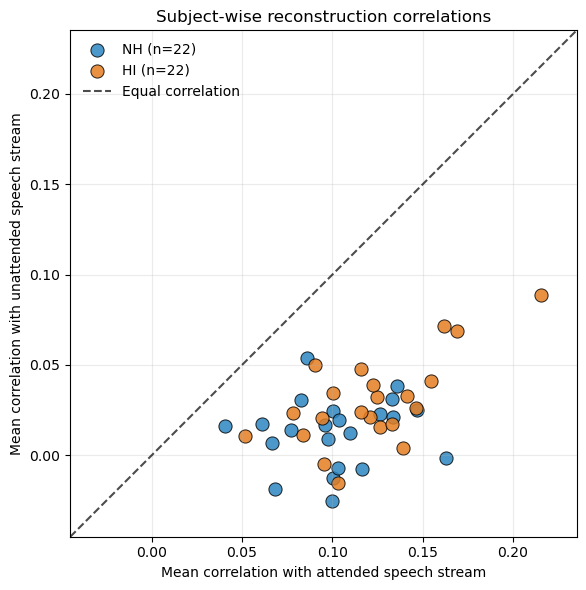

Saved figure to: reports\figures\subjectwise_attended_vs_unattended_correlations.png
Saved figure to: reports\figures\subjectwise_attended_vs_unattended_correlations.pdf


,subject,group_label,mean_r_att,mean_r_ign,decoding_accuracy,n_trials,r_diff
0,sub-001,HI,0.115582,0.047934,0.96875,32,0.067648
1,sub-002,HI,0.126482,0.015754,1.00000,32,0.110729
2,sub-003,HI,0.090392,0.049869,0.75000,32,0.040523
3,sub-004,HI,0.168810,0.068791,0.90625,32,0.100019
4,sub-005,HI,0.084005,0.010945,0.90625,32,0.073061
5,sub-006,HI,0.146317,0.025906,0.96875,32,0.120411
6,sub-007,HI,0.051770,0.010569,0.78125,32,0.041201
7,sub-008,HI,0.100076,0.034453,0.84375,32,0.065623
8,sub-009,HI,0.161852,0.071451,0.87500,32,0.090401
9,sub-010,HI,0.094257,0.020394,0.81250,32,0.073862


In [30]:
# --------------------------------------------------
# Plot attended vs unattended reconstruction correlations
# One point per subject, colored by hearing group
# --------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Load combined trial-level data
# -----------------------------

RESULTS_CSV = Path("statistics1/aad_trial_level_results.csv")

# Fallback if the notebook is already inside the statistics folder
if not RESULTS_CSV.exists():
    RESULTS_CSV = Path("aad_trial_level_results.csv")

df = pd.read_csv(RESULTS_CSV)

print("Loaded file:", RESULTS_CSV)
print("Columns in file:")
print(df.columns.tolist())


# -----------------------------
# Check required columns
# -----------------------------

required_corr_cols = {"subject", "r_att", "r_ign"}
missing = required_corr_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in results file: {missing}")


# -----------------------------
# Create robust group label
# -----------------------------

if "hearing_status" in df.columns:
    # Try to standardize whatever text is in hearing_status
    raw_status = df["hearing_status"].astype(str).str.strip().str.upper()

    # Map common possible variants to NH / HI
    status_map = {
        "NH": "NH",
        "NORMAL HEARING": "NH",
        "NORMAL-HEARING": "NH",
        "NORMAL": "NH",
        "HI": "HI",
        "HEARING IMPAIRED": "HI",
        "HEARING-IMPAIRED": "HI",
        "IMPAIRED": "HI",
    }

    df["group_label"] = raw_status.map(status_map)

elif "group_HI" in df.columns:
    # Fallback to binary column
    df["group_label"] = df["group_HI"].map({0: "NH", 1: "HI"})

else:
    raise ValueError(
        "Could not find either 'hearing_status' or 'group_HI' in the file."
    )

# Final safety check
if df["group_label"].isna().any():
    unknown_vals = df.loc[df["group_label"].isna(), :].copy()
    if "hearing_status" in df.columns:
        print("Unrecognized hearing_status values:")
        print(df.loc[df["group_label"].isna(), "hearing_status"].unique())
    raise ValueError(
        "Some group labels could not be mapped to NH/HI. "
        "See printed values above and extend the mapping if needed."
    )

print("\nUnique group labels after cleaning:")
print(df["group_label"].unique())


# -----------------------------
# Average correlations per subject
# using Fisher z-transform
# -----------------------------

def fisher_mean_r(x):
    """
    Average correlations using Fisher z-transform.
    Preferred over directly averaging Pearson r values.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    x = np.clip(x, -0.999999, 0.999999)  # avoid infinite arctanh
    return np.tanh(np.mean(np.arctanh(x)))


agg_dict = {
    "mean_r_att": ("r_att", fisher_mean_r),
    "mean_r_ign": ("r_ign", fisher_mean_r),
}

if "correct" in df.columns:
    agg_dict["decoding_accuracy"] = ("correct", "mean")

if "trial_index" in df.columns:
    agg_dict["n_trials"] = ("trial_index", "count")
else:
    agg_dict["n_trials"] = ("subject", "size")


subject_corr_df = (
    df.groupby(["subject", "group_label"], as_index=False)
      .agg(**agg_dict)
)

subject_corr_df["r_diff"] = (
    subject_corr_df["mean_r_att"] - subject_corr_df["mean_r_ign"]
)

print("\nSubject-level summary:")
display(subject_corr_df.head())


# -----------------------------
# Plot
# -----------------------------

REPORT_FIG_DIR = Path("reports") / "figures"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

colors = {
    "HI": "#E67E22",   # orange
    "NH": "#2E86C1",   # blue
}

fig, ax = plt.subplots(figsize=(7, 6))

for group in ["NH", "HI"]:
    group_df = subject_corr_df[subject_corr_df["group_label"] == group]
    if len(group_df) == 0:
        continue

    ax.scatter(
        group_df["mean_r_att"],
        group_df["mean_r_ign"],
        s=90,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.7,
        color=colors[group],
        label=f"{group} (n={len(group_df)})",
    )

# Diagonal line: equal correlation with attended and unattended streams
all_vals = pd.concat([
    subject_corr_df["mean_r_att"],
    subject_corr_df["mean_r_ign"]
])

pad = 0.02
lim_min = all_vals.min() - pad
lim_max = all_vals.max() + pad

ax.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--",
    linewidth=1.5,
    color="black",
    alpha=0.7,
    label="Equal correlation"
)

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Mean correlation with attended speech stream")
ax.set_ylabel("Mean correlation with unattended speech stream")
ax.set_title("Subject-wise reconstruction correlations")

ax.legend(frameon=False)
ax.grid(alpha=0.25)

plt.tight_layout()

fig_path_png = REPORT_FIG_DIR / "subjectwise_attended_vs_unattended_correlations.png"
fig_path_pdf = REPORT_FIG_DIR / "subjectwise_attended_vs_unattended_correlations.pdf"

plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {fig_path_png}")
print(f"Saved figure to: {fig_path_pdf}")


# -----------------------------
# Optional: show the summary table
# -----------------------------

subject_corr_df = subject_corr_df.sort_values("subject").reset_index(drop=True)
display(subject_corr_df)

Current directory: c:\Projects\AAD_Fagprojekt_v2\statistics1
Project root: c:\Projects\AAD_Fagprojekt_v2
Loaded file: c:\Projects\AAD_Fagprojekt_v2\statistics1\aad_trial_level_results.csv
Columns in file:
['subject', 'hearing_status', 'group_HI', 'scalp_only', 'trial_index', 'r_att', 'r_ign', 'r_diff', 'correct', 'subject_decoding_accuracy', 'subject_n_trials', 'subject_n_correct', 'summary_path']

Unique group labels after cleaning:
<StringArray>
['HI', 'NH']
Length: 2, dtype: str

Subject-level summary:


,subject,group_label,mean_r_att,mean_r_ign,decoding_accuracy,n_trials,r_diff
0,sub-001,HI,0.115582,0.047934,0.96875,32,0.067648
1,sub-002,HI,0.126482,0.015754,1.00000,32,0.110729
2,sub-003,HI,0.090392,0.049869,0.75000,32,0.040523
3,sub-004,HI,0.168810,0.068791,0.90625,32,0.100019
4,sub-005,HI,0.084005,0.010945,0.90625,32,0.073061


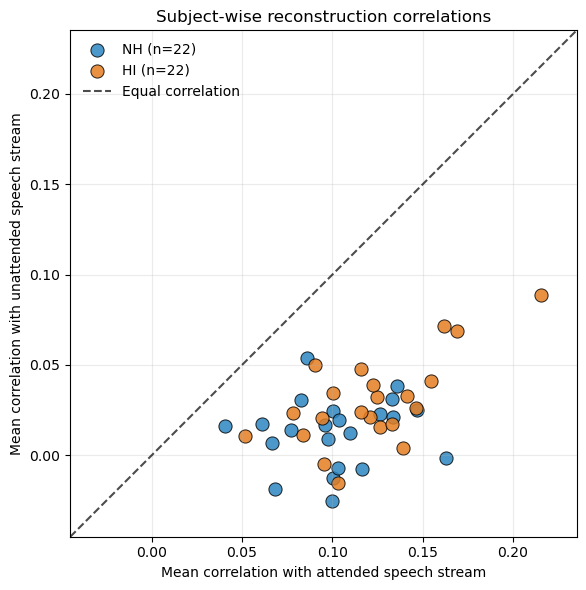

Saved figure to: c:\Projects\AAD_Fagprojekt_v2\reports\figures\subjectwise_attended_vs_unattended_correlations.png
Saved figure to: c:\Projects\AAD_Fagprojekt_v2\reports\figures\subjectwise_attended_vs_unattended_correlations.pdf


,subject,group_label,mean_r_att,mean_r_ign,decoding_accuracy,n_trials,r_diff
0,sub-001,HI,0.115582,0.047934,0.96875,32,0.067648
1,sub-002,HI,0.126482,0.015754,1.00000,32,0.110729
2,sub-003,HI,0.090392,0.049869,0.75000,32,0.040523
3,sub-004,HI,0.168810,0.068791,0.90625,32,0.100019
4,sub-005,HI,0.084005,0.010945,0.90625,32,0.073061
5,sub-006,HI,0.146317,0.025906,0.96875,32,0.120411
6,sub-007,HI,0.051770,0.010569,0.78125,32,0.041201
7,sub-008,HI,0.100076,0.034453,0.84375,32,0.065623
8,sub-009,HI,0.161852,0.071451,0.87500,32,0.090401
9,sub-010,HI,0.094257,0.020394,0.81250,32,0.073862


In [31]:
# --------------------------------------------------
# Plot attended vs unattended reconstruction correlations
# One point per subject, colored by hearing group
# --------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Define project root
# -----------------------------

# If notebook is inside statistics1, project root is one level up.
# If notebook is already in project root, project root is current folder.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "statistics1":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

print("Current directory:", CURRENT_DIR)
print("Project root:", PROJECT_ROOT)


# -----------------------------
# Load combined trial-level data
# -----------------------------

RESULTS_CSV = PROJECT_ROOT / "statistics1" / "aad_trial_level_results.csv"

if not RESULTS_CSV.exists():
    raise FileNotFoundError(f"Could not find results file: {RESULTS_CSV}")

df = pd.read_csv(RESULTS_CSV)

print("Loaded file:", RESULTS_CSV)
print("Columns in file:")
print(df.columns.tolist())


# -----------------------------
# Check required columns
# -----------------------------

required_corr_cols = {"subject", "r_att", "r_ign"}
missing = required_corr_cols - set(df.columns)

if missing:
    raise ValueError(f"Missing required columns in results file: {missing}")


# -----------------------------
# Create robust group label
# -----------------------------

if "hearing_status" in df.columns:
    raw_status = df["hearing_status"].astype(str).str.strip().str.upper()

    status_map = {
        "NH": "NH",
        "NORMAL HEARING": "NH",
        "NORMAL-HEARING": "NH",
        "NORMAL": "NH",
        "HI": "HI",
        "HEARING IMPAIRED": "HI",
        "HEARING-IMPAIRED": "HI",
        "IMPAIRED": "HI",
    }

    df["group_label"] = raw_status.map(status_map)

elif "group_HI" in df.columns:
    df["group_label"] = df["group_HI"].map({0: "NH", 1: "HI"})

else:
    raise ValueError(
        "Could not find either 'hearing_status' or 'group_HI' in the file."
    )

if df["group_label"].isna().any():
    if "hearing_status" in df.columns:
        print("Unrecognized hearing_status values:")
        print(df.loc[df["group_label"].isna(), "hearing_status"].unique())

    raise ValueError(
        "Some group labels could not be mapped to NH/HI. "
        "See printed values above and extend the mapping if needed."
    )

print("\nUnique group labels after cleaning:")
print(df["group_label"].unique())


# -----------------------------
# Average correlations per subject
# using Fisher z-transform
# -----------------------------

def fisher_mean_r(x):
    """
    Average correlations using Fisher z-transform.
    Preferred over directly averaging Pearson r values.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    x = np.clip(x, -0.999999, 0.999999)
    return np.tanh(np.mean(np.arctanh(x)))


agg_dict = {
    "mean_r_att": ("r_att", fisher_mean_r),
    "mean_r_ign": ("r_ign", fisher_mean_r),
}

if "correct" in df.columns:
    agg_dict["decoding_accuracy"] = ("correct", "mean")

if "trial_index" in df.columns:
    agg_dict["n_trials"] = ("trial_index", "count")
else:
    agg_dict["n_trials"] = ("subject", "size")


subject_corr_df = (
    df.groupby(["subject", "group_label"], as_index=False)
      .agg(**agg_dict)
)

subject_corr_df["r_diff"] = (
    subject_corr_df["mean_r_att"] - subject_corr_df["mean_r_ign"]
)

print("\nSubject-level summary:")
display(subject_corr_df.head())


# -----------------------------
# Plot
# -----------------------------

# This now saves to reports/figures in the project root
REPORT_FIG_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

colors = {
    "HI": "#E67E22",   # orange
    "NH": "#2E86C1",   # blue
}

fig, ax = plt.subplots(figsize=(7, 6))

for group in ["NH", "HI"]:
    group_df = subject_corr_df[subject_corr_df["group_label"] == group]

    if len(group_df) == 0:
        continue

    ax.scatter(
        group_df["mean_r_att"],
        group_df["mean_r_ign"],
        s=90,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.7,
        color=colors[group],
        label=f"{group} (n={len(group_df)})",
    )

# Diagonal line: equal correlation with attended and unattended streams
all_vals = pd.concat([
    subject_corr_df["mean_r_att"],
    subject_corr_df["mean_r_ign"]
])

pad = 0.02
lim_min = all_vals.min() - pad
lim_max = all_vals.max() + pad

ax.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--",
    linewidth=1.5,
    color="black",
    alpha=0.7,
    label="Equal correlation"
)

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Mean correlation with attended speech stream")
ax.set_ylabel("Mean correlation with unattended speech stream")
ax.set_title("Subject-wise reconstruction correlations")

ax.legend(frameon=False)
ax.grid(alpha=0.25)

plt.tight_layout()

fig_path_png = REPORT_FIG_DIR / "subjectwise_attended_vs_unattended_correlations.png"
fig_path_pdf = REPORT_FIG_DIR / "subjectwise_attended_vs_unattended_correlations.pdf"

plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {fig_path_png}")
print(f"Saved figure to: {fig_path_pdf}")


# -----------------------------
# Optional: show the summary table
# -----------------------------

subject_corr_df = subject_corr_df.sort_values("subject").reset_index(drop=True)
display(subject_corr_df)

**Envelope + onsets**

> Accuracies

In [54]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Path setup
# --------------------------------------------------
# Assumes the notebook is inside the statistics folder.
# If you run it from statistics/, this will work directly.

STAT_DIR = Path.cwd()
PROJECT_ROOT = STAT_DIR.parent

# Input file from combine_results.py
TRIAL_RESULTS_PATH = STAT_DIR / "envelope_onsets" / "aad_trial_level_results_env_onset.csv"

# Output folder for report figures
REPORT_FIG_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)

print("Statistics folder:", STAT_DIR)
print("Project root:", PROJECT_ROOT)
print("Trial results file:", TRIAL_RESULTS_PATH)
print("Figure output folder:", REPORT_FIG_DIR)

Statistics folder: c:\Projects\AAD_Fagprojekt_v2\statistics1
Project root: c:\Projects\AAD_Fagprojekt_v2
Trial results file: c:\Projects\AAD_Fagprojekt_v2\statistics1\envelope_onsets\aad_trial_level_results_env_onset.csv
Figure output folder: c:\Projects\AAD_Fagprojekt_v2\reports\figures


In [ ]:
# --------------------------------------------------
# Load env+onset trial-level results and create subject_acc_df
# --------------------------------------------------

trial_df = pd.read_csv(TRIAL_RESULTS_PATH)

print("Trial-level shape before filtering:", trial_df.shape)
print("Columns:")
print(trial_df.columns.tolist())

display(trial_df.head())


# --------------------------------------------------
# Optional scalp-only filtering
# --------------------------------------------------

if "scalp_only" in trial_df.columns:
    trial_df = trial_df[trial_df["scalp_only"] == True].copy()
    print("\nFiltered to scalp_only == True")
else:
    print("\nNo 'scalp_only' column found. Assuming scalp-only data.")
    print("This is okay for env+onset if the file only contains scalp EEG results.")

print("Trial-level shape after optional scalp filtering:", trial_df.shape)


# --------------------------------------------------
# Make sure the correctness column exists
# --------------------------------------------------

if "correct" not in trial_df.columns:
    raise ValueError(
        "The env+onset trial file does not contain a 'correct' column. "
        "Check that you are loading the right CSV file."
    )

trial_df["correct"] = pd.to_numeric(trial_df["correct"], errors="coerce")
trial_df = trial_df.dropna(subset=["correct"]).copy()

print("Trial-level shape after removing missing correct values:", trial_df.shape)


# --------------------------------------------------
# Add hearing status from participants.tsv if needed
# --------------------------------------------------

# Change this path if your participants.tsv is somewhere else
PARTICIPANTS_PATH = PROJECT_ROOT / "participants.tsv"

# Check whether hearing status is actually usable
has_hearing_status = (
    "hearing_status" in trial_df.columns
    and trial_df["hearing_status"].notna().any()
)

has_group_HI = (
    "group_HI" in trial_df.columns
    and trial_df["group_HI"].notna().any()
)

if not has_hearing_status and not has_group_HI:
    print("\nNo usable hearing_status/group_HI found in env+onset CSV.")
    print("Trying to merge hearing status from:", PARTICIPANTS_PATH)

    if not PARTICIPANTS_PATH.exists():
        raise FileNotFoundError(
            f"Could not find participants.tsv at: {PARTICIPANTS_PATH}\n"
            "Set PARTICIPANTS_PATH to the correct location of participants.tsv."
        )

    participants_df = pd.read_csv(PARTICIPANTS_PATH, sep="\t")

    print("\nParticipants columns:")
    print(participants_df.columns.tolist())

    if "participant_id" not in participants_df.columns:
        raise ValueError("participants.tsv does not contain 'participant_id'.")

    if "hearing_status" not in participants_df.columns:
        raise ValueError("participants.tsv does not contain 'hearing_status'.")

    participants_df = participants_df[["participant_id", "hearing_status"]].copy()
    participants_df = participants_df.rename(columns={"participant_id": "subject"})

    trial_df = trial_df.drop(columns=["hearing_status", "group_HI"], errors="ignore")
    trial_df = trial_df.merge(participants_df, on="subject", how="left")

    if trial_df["hearing_status"].isna().any():
        missing_subjects = trial_df.loc[
            trial_df["hearing_status"].isna(), "subject"
        ].unique()

        raise ValueError(
            "Some subjects were not found in participants.tsv:\n"
            f"{missing_subjects}"
        )


# --------------------------------------------------
# Create clean group labels
# --------------------------------------------------

if "hearing_status" in trial_df.columns and trial_df["hearing_status"].notna().any():
    raw_group = (
        trial_df["hearing_status"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

elif "group_HI" in trial_df.columns and trial_df["group_HI"].notna().any():
    group_hi_numeric = pd.to_numeric(trial_df["group_HI"], errors="coerce")
    raw_group = group_hi_numeric.map({
        0: "NH",
        1: "HI",
    })

else:
    raise ValueError(
        "Still could not find usable hearing-status information. "
        "Check participants.tsv and subject IDs."
    )


status_map = {
    "NH": "NH",
    "NORMAL HEARING": "NH",
    "NORMAL-HEARING": "NH",
    "NORMAL": "NH",
    "HI": "HI",
    "HEARING IMPAIRED": "HI",
    "HEARING-IMPAIRED": "HI",
    "IMPAIRED": "HI",
}

trial_df["group_label"] = raw_group.map(status_map)

if trial_df["group_label"].isna().any():
    print("Unrecognized group labels:")
    print(raw_group[trial_df["group_label"].isna()].unique())

    raise ValueError("Some hearing-status values could not be mapped to HI/NH.")

trial_df["hearing_status"] = trial_df["group_label"]
trial_df["group_HI"] = trial_df["group_label"].map({
    "NH": 0,
    "HI": 1,
})


print("\nNumber of subjects:", trial_df["subject"].nunique())
print("\nSubjects by hearing status:")
display(trial_df.groupby("hearing_status")["subject"].nunique())


# --------------------------------------------------
# One row per subject for subject-wise accuracy plotting
# --------------------------------------------------

subject_acc_df = (
    trial_df.groupby(["subject", "hearing_status", "group_HI"], as_index=False)
    .agg(
        decoding_accuracy=("correct", "mean"),
        n_trials=("correct", "size"),
        n_correct=("correct", "sum"),
    )
)

subject_acc_df["group_label"] = subject_acc_df["hearing_status"]

subject_acc_df["subject_num"] = (
    subject_acc_df["subject"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(int)
)

subject_acc_df["group_order"] = subject_acc_df["group_label"].map({
    "HI": 0,
    "NH": 1,
})

subject_acc_df = (
    subject_acc_df
    .sort_values(["group_order", "subject_num"])
    .reset_index(drop=True)
)

print("\nCreated subject_acc_df:")
print("Shape:", subject_acc_df.shape)
display(subject_acc_df.head())

Trial-level shape before filtering: (1408, 31)
Columns:
['subject', 'hearing_status', 'group_HI', 'trial_index', 'correct', 'score', 'r_att_envelope', 'r_ign_envelope', 'diff_envelope', 'r_att_onset', 'r_ign_onset', 'diff_onset', 'r_diff_combined', 'subject_decoding_accuracy', 'subject_n_trials', 'subject_n_features', 'predictor_names', 'input_path', 'tstart', 'tstop', 'basis', 'basis_window', 'test', 'partitions', 'error', 'selective_stopping', 'scale_data', 'score_mode', 'feature_weights', 'summary_path', 'trial_csv_path']


,subject,hearing_status,group_HI,trial_index,correct,score,r_att_envelope,r_ign_envelope,diff_envelope,r_att_onset,r_ign_onset,diff_onset,r_diff_combined,subject_decoding_accuracy,subject_n_trials,subject_n_features,predictor_names,input_path,tstart,tstop,basis,basis_window,test,partitions,error,selective_stopping,scale_data,score_mode,feature_weights,summary_path,trial_csv_path
0,sub-001,NaN,NaN,0,1,0.075024,0.106912,0.045254,0.061658,0.133078,0.044688,0.088390,0.075024,0.9375,32,2,"envelope,onset",data/processed/env_onset/sub-001_mtrf_env_onse...,-0.5,0.0,0.05,hamming,1,NaN,l2,1,True,mean,"1.0,1.0",results_env_onset\sub-001\sub-001_backward_mtr...,results_env_onset\sub-001\sub-001_backward_mtr...
1,sub-001,NaN,NaN,1,1,0.129550,0.155028,0.015747,0.139281,0.177719,0.057900,0.119819,0.129550,0.9375,32,2,"envelope,onset",data/processed/env_onset/sub-001_mtrf_env_onse...,-0.5,0.0,0.05,hamming,1,NaN,l2,1,True,mean,"1.0,1.0",results_env_onset\sub-001\sub-001_backward_mtr...,results_env_onset\sub-001\sub-001_backward_mtr...
2,sub-001,NaN,NaN,2,1,0.100022,0.070399,-0.008114,0.078513,0.083431,-0.038100,0.121531,0.100022,0.9375,32,2,"envelope,onset",data/processed/env_onset/sub-001_mtrf_env_onse...,-0.5,0.0,0.05,hamming,1,NaN,l2,1,True,mean,"1.0,1.0",results_env_onset\sub-001\sub-001_backward_mtr...,results_env_onset\sub-001\sub-001_backward_mtr...
3,sub-001,NaN,NaN,3,0,-0.018967,0.117675,0.083960,0.033715,0.048953,0.120601,-0.071649,-0.018967,0.9375,32,2,"envelope,onset",data/processed/env_onset/sub-001_mtrf_env_onse...,-0.5,0.0,0.05,hamming,1,NaN,l2,1,True,mean,"1.0,1.0",results_env_onset\sub-001\sub-001_backward_mtr...,results_env_onset\sub-001\sub-001_backward_mtr...
4,sub-001,NaN,NaN,4,1,0.123232,0.068591,-0.031645,0.100237,0.112976,-0.033251,0.146227,0.123232,0.9375,32,2,"envelope,onset",data/processed/env_onset/sub-001_mtrf_env_onse...,-0.5,0.0,0.05,hamming,1,NaN,l2,1,True,mean,"1.0,1.0",results_env_onset\sub-001\sub-001_backward_mtr...,results_env_onset\sub-001\sub-001_backward_mtr...



No 'scalp_only' column found. Skipping scalp-only filtering.
This is okay for env+onset if the file only contains scalp EEG results.
Trial-level shape after optional scalp filtering: (1408, 31)
Trial-level shape after removing missing correct values: (1408, 31)

No usable hearing_status/group_HI found in env+onset CSV.
Trying to merge hearing status from: c:\Projects\AAD_Fagprojekt_v2\participants.tsv

Participants columns:
['participant_id', 'age', 'hearing_status', 'ear_eeg', 'handedness', 'gender', 'speech_reception_thresholds', 'digit_span_backward', 'digit_span_forward', 'FT_test_temporal', 'FT_test_spectral', 'SSQ_speech', 'SSQ_spatial', 'SSQ_qual', 'audiogram_right_ear_125Hz', 'audiogram_right_ear_250Hz', 'audiogram_right_ear_500Hz', 'audiogram_right_ear_1000Hz', 'audiogram_right_ear_2000Hz', 'audiogram_right_ear_3000Hz', 'audiogram_right_ear_4000Hz', 'audiogram_right_ear_6000Hz', 'audiogram_right_ear_8000Hz', 'audiogram_left_ear_125Hz', 'audiogram_left_ear_250Hz', 'audiogram_l

hearing_status
HI    22
NH    22
Name: subject, dtype: int64


Created subject_acc_df:
Shape: (44, 9)


,subject,hearing_status,group_HI,decoding_accuracy,n_trials,n_correct,group_label,subject_num,group_order
0,sub-001,HI,1,0.93750,32,30,HI,1,0
1,sub-002,HI,1,0.93750,32,30,HI,2,0
2,sub-003,HI,1,0.65625,32,21,HI,3,0
3,sub-004,HI,1,0.93750,32,30,HI,4,0
4,sub-005,HI,1,0.90625,32,29,HI,5,0


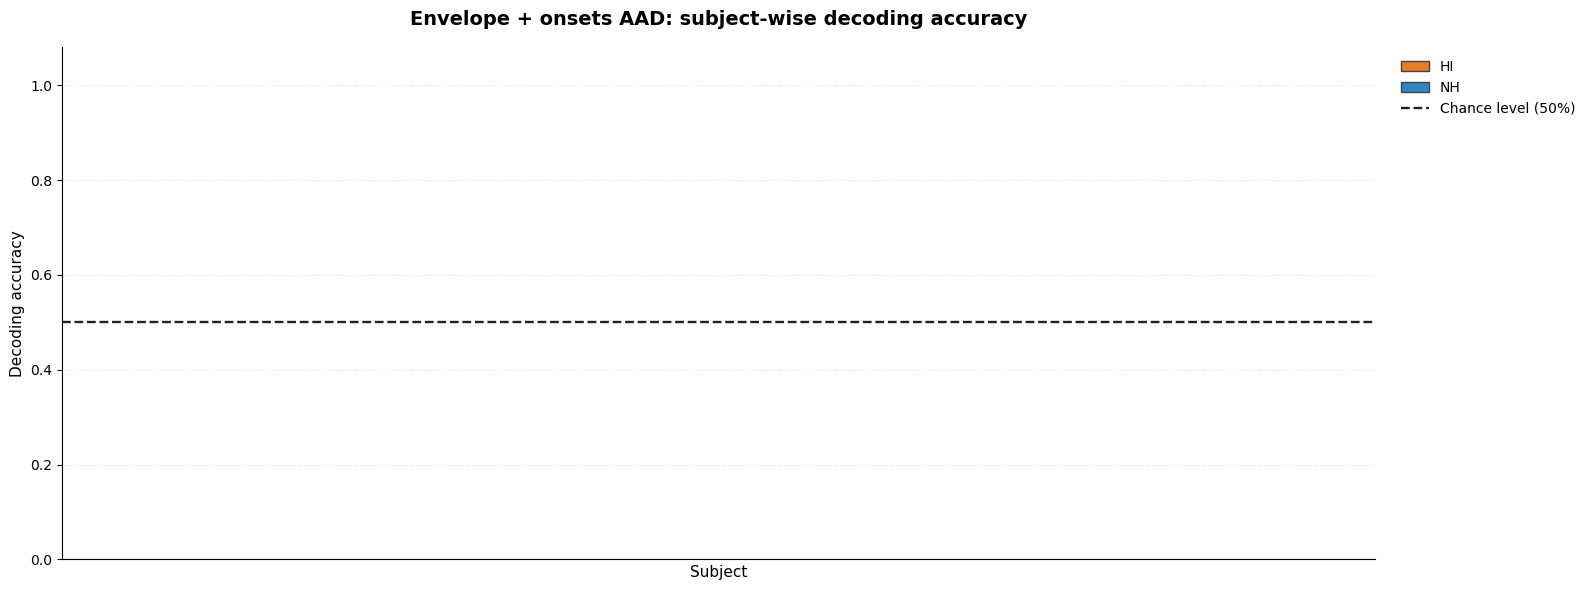

Saved figure to:
c:\Projects\AAD_Fagprojekt_v2\reports\figures\env_onset_accuracy_plot.png


In [45]:
# --------------------------------------------------
# Plot subject-wise decoding accuracy
# Envelope + onsets pipeline
# --------------------------------------------------

# Output folder for report figures
REPORT_FIG_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Colors
COLOR_HI = "#E67E22"   # orange
COLOR_NH = "#2E86C1"   # blue
COLOR_CHANCE = "#222222"

# Make sure subjects are sorted clearly
plot_df = subject_acc_df.copy()

plot_df["subject_num"] = (
    plot_df["subject"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(int)
)

plot_df["group_label"] = (
    plot_df["group_label"]
    .astype(str)
    .str.strip()
    .str.upper()
)

plot_df["group_order"] = plot_df["group_label"].map({"HI": 0, "NH": 1})
plot_df = plot_df.sort_values(["group_order", "subject_num"]).reset_index(drop=True)

# Bar positions and colors
x = np.arange(len(plot_df))
bar_colors = plot_df["group_label"].map({
    "HI": COLOR_HI,
    "NH": COLOR_NH,
})

fig, ax = plt.subplots(figsize=(16, 6))

# Light background shading for the two groups
hi_count = (plot_df["group_label"] == "HI").sum()
nh_count = (plot_df["group_label"] == "NH").sum()

if hi_count > 0:
    ax.axvspan(
        -0.5,
        hi_count - 0.5,
        color=COLOR_HI,
        alpha=0.08,
        zorder=0,
    )

if nh_count > 0:
    ax.axvspan(
        hi_count - 0.5,
        len(plot_df) - 0.5,
        color=COLOR_NH,
        alpha=0.08,
        zorder=0,
    )

# Bars
ax.bar(
    x,
    plot_df["decoding_accuracy"],
    color=bar_colors,
    edgecolor="#444444",
    linewidth=0.7,
    zorder=3,
)

# Chance level
ax.axhline(
    0.5,
    color=COLOR_CHANCE,
    linestyle="--",
    linewidth=1.7,
    label="Chance level (50%)",
    zorder=4,
)

# Separator between HI and NH
if hi_count > 0 and nh_count > 0:
    ax.axvline(
        hi_count - 0.5,
        color="gray",
        linewidth=1.2,
        alpha=0.7,
        zorder=5,
    )

# Group labels above plot
if hi_count > 0:
    ax.text(
        (hi_count - 1) / 2,
        1.025,
        "HI",
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold",
        color=COLOR_HI,
    )

if nh_count > 0:
    ax.text(
        hi_count + (nh_count - 1) / 2,
        1.025,
        "NH",
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold",
        color=COLOR_NH,
    )

# Axis formatting
ax.set_title(
    "Envelope + onsets AAD: subject-wise decoding accuracy",
    fontsize=14,
    weight="bold",
    pad=16,
)

ax.set_xlabel("Subject", fontsize=11)
ax.set_ylabel("Decoding accuracy", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["subject"], rotation=90)

ax.set_ylim(0, 1.08)
ax.yaxis.grid(True, linestyle=":", alpha=0.35, zorder=1)
ax.set_axisbelow(True)

# Cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend outside the plotting area
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_handles = [
    Patch(facecolor=COLOR_HI, edgecolor="#444444", label="HI"),
    Patch(facecolor=COLOR_NH, edgecolor="#444444", label="NH"),
    Line2D(
        [0],
        [0],
        color=COLOR_CHANCE,
        linestyle="--",
        linewidth=1.7,
        label="Chance level (50%)",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=False,
)

fig.tight_layout()

# Save figure as PNG only.
# New filename so it does not overwrite the baseline envelope figure.
out_png = REPORT_FIG_DIR / "env_onset_accuracy_plot.png"

fig.savefig(out_png, dpi=300, bbox_inches="tight")

plt.show()

print("Saved figure to:")
print(out_png)